# Лекция.  Метрики ранжирования

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

## § 1. Игрушечный пример

### 1.1. Контекст

Представьте себе юридическую фирму — назовем её, скажем, «Квитанция & Циферки». Да, иронично, но это неважно. Занимаемся мы банкротством юридических лиц. Имеем сайт. На этот сайт, как вы понимаете, заходят потенциальные клиенты. Любопытные, отчаявшиеся, или просто те, кому стало скучно. Заходят, бродят по страницам и… уходят. Потому что заказ у нас — не онлайн-опция. Это не флажок «купить в один клик». Это серьёзное дело. Клиент должен посмотреть на нас через экран, потом — приехать в офис, и только там мы с ним подписываем гору документов. Всё по старинке, с бумагой, ручками и человеческим взглядом.

Но мы не хотим сидеть и ждать милости от судьбы. Мы — прогрессивные. Хотим работать на опережение. А потому посадили в колл-центр девушек — пусть звонят всем, кто хоть раз заглянул на наш сайт. Стратегия, прямо скажем, не блещет эффективностью. Почему? Потому что заходят многие, а заказывают — единицы. А звонки — дело ресурсоёмкое. И неблагодарное. Но таков контекст, коллеги. Исходим из него.

### 1.2. Модель

Нашу проблему мы решаем следующим образом. У нас есть исторические данные по клиентам: сколько раз заходил на сайт, с какого устройства, какие разделы просматривал, сколько времени на них провёл — ну, вы поняли. Всё, что можно собрать, мы собираем. И, что самое главное, у нас есть целевая отметка — сделал ли этот клиент в итоге заказ или нет. Золотой билет, так сказать.

Мы сочинили две модели. Назовём их скромно — модель A и модель B. Прогнали на тестовой выборке и получили буквально одно и то же. Смотрите:

In [2]:
y_true   = [1, 1, 0, 1, 1, 0, 0, 1, 0, 0]
y_pred_A = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
y_pred_B = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

df=pd.DataFrame()
df['client'] = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']
df['y_true'] = y_true
df['y_pred_A'] = y_pred_A
df['y_pred_B'] = y_pred_B
display(df)

print('A:  accuracy =', round(accuracy_score(y_true, y_pred_A), 4))
print('A: precision =', round(precision_score(y_true, y_pred_A), 4))
print('A:    recall =', round(recall_score(y_true, y_pred_A), 4))
print('A:        f1 =', round(f1_score(y_true, y_pred_A), 4))
print('')
print('B:  accuracy =', round(accuracy_score(y_true, y_pred_B), 4))
print('B: precision =', round(precision_score(y_true, y_pred_B), 4))
print('B:    recall =', round(recall_score(y_true, y_pred_B), 4))
print('B:        f1 =', round(f1_score(y_true, y_pred_B), 4))

,client,y_true,y_pred_A,y_pred_B
0,C1,1,1,1
1,C2,1,1,1
2,C3,0,1,1
3,C4,1,1,1
4,C5,1,1,1
5,C6,0,0,0
6,C7,0,0,0
7,C8,1,0,0
8,C9,0,0,0
9,C10,0,0,0


A:  accuracy = 0.8
A: precision = 0.8
A:    recall = 0.8
A:        f1 = 0.8

B:  accuracy = 0.8
B: precision = 0.8
B:    recall = 0.8
B:        f1 = 0.8


Неудивительно, что все метрики — accuracy, precision, recall, f1 — у них совпадают. Абсолютно. И вот тут, дорогие коллеги, начинается самое интересное. Потому что если мы остановимся на этом, мы никогда не узнаем, какая из моделей действительно лучше для нашей бизнес-задачи. А ведь разница есть. И она существенна.

### 1.3. Эффект

Теперь наши барышни из колл-центра обзванивают только тех, кого модели признали перспективными. И это, согласитесь, уже прогресс — не молотить же по базе вслепую, как в прошлой жизни. Но есть одно «но». Двадцать процентов звонков всё равно улетают в никуда. В пустоту. В чёрную дыру бизнес-процессов. А каждый такой звонок — это деньги. Девчонкам, знаете ли, надо платить зарплату. И не просто платить, а платить вовремя, иначе они уйдут к конкурентам, а конкуренты у нас — как грибов после дождя на рынке банкротств.

Но это ещё не всё. Каждый звонок — это ещё и время. Пока наша милая сотрудница обрабатывает бесперспективного клиента, другого, по-настоящему горячего, могут перехватить те самые конкуренты. А их, как я уже сказал, пруд пруди. Ситуация, знаете ли, напоминает игру в музыкальные стулья, только ставки выше.

— И в чем же проблема? — спросите вы с наивным блеском в глазах. — Очевидно же: подкрутить порог бинаризации, поднять precision — и дело с концом!

О, если бы всё было так просто. Если бы мир классификации укладывался в одну ручку-крутилку. Повышая precision, мы неизбежно опускаем recall. А это значит, что мы начнём пропускать потенциальных клиентов. Тех самых, которые могли бы принести нам деньги, но остались за бортом, потому что мы слишком боялись ложных срабатываний.

### 1.4. Детализация

Но мы ведь люди грамотные, не правда ли? Мы знаем, что любой уважающий себя классификатор возвращает не только метку класса, но и вероятность принадлежности к этому классу. Выводим вероятности — и оказывается, наши модели A и B не такие уж и одинаковые. Различие — в клиенте C3.

In [3]:
y_true         = [  1,   1,   0,   1,   1,   0,   0,   1,   0,   0]
y_pred_proba_A = [0.7, 0.6, 0.9, 0.8, 0.8, 0.4, 0.1, 0.2, 0.3, 0.2]
y_pred_proba_B = [0.7, 0.6, 0.5, 0.8, 0.8, 0.4, 0.1, 0.2, 0.3, 0.2]

df['y_pred_proba_A'] = y_pred_proba_A
df['y_pred_proba_B'] = y_pred_proba_B
display(df)

,client,y_true,y_pred_A,y_pred_B,y_pred_proba_A,y_pred_proba_B
0,C1,1,1,1,0.7,0.7
1,C2,1,1,1,0.6,0.6
2,C3,0,1,1,0.9,0.5
3,C4,1,1,1,0.8,0.8
4,C5,1,1,1,0.8,0.8
5,C6,0,0,0,0.4,0.4
6,C7,0,0,0,0.1,0.1
7,C8,1,0,0,0.2,0.2
8,C9,0,0,0,0.3,0.3
9,C10,0,0,0,0.2,0.2


Интуиция нам уже шепчет: «Модель B — лучше, избавьтесь от модели A, используйте B». Но давайте разберёмся, почему.

Модель A откровенно врёт. Она говорит: «В первую очередь звоните клиенту C3». А ему звонить не надо — он заказ не сделает. «Потом — продолжает молель A, — звоните клиентам C4 и C5, они одинаковые, порядок не важен. Затем — клиенту C1. И в самом конце, после всех — клиенту C2». Стыд и позор, а не рекомендация.

Модель B на рассуждает более здраво: «Сначала — клиенты C4 и C5. Оба перспективны, порядок не важен. Потом — C1. Затем — C2. И только в самую последнюю очередь — C3, он бесперспективен». И в этом она абсолютно права.

И вот здесь мы упираемся в стену. Для того чтобы отличать модель A от B не на уровне «ну, кажется, эта лучше», а строго, формально, научно, — нам нужна новая метрика. Потому что классические метрики классификации не раличают единицы: они, с их точки зрения, неразличимы (как, впрочем, и нули). А они — разные. Одни — перспективные, другие — нет. Для нашей бизнес-задачи важен именно порядок: кого ставить первым, кого — последним. 

И это, коллеги, уже совсем другая история.

### 1.5. Оценка

Итак, коллеги, нам нужна метрика. Не новая — это было бы слишком громко сказано. Нам нужна другая метрика. Метрика, которая чувствует порядок. Которая скажет нам не просто «это единица, а это ноль», а «эта единица увереннее, чем та, и вот насколько».

Рассуждаем так.

Во-первых, делим все наши наблюдения на две благородные группы: истинные единицы и истинные нули. Кодом это выглядит так:

In [4]:
mask = df['y_true'] == 1
df_1 = df.loc[mask]
df_2 = df.loc[~mask]
display(df_1)
display(df_2)

,client,y_true,y_pred_A,y_pred_B,y_pred_proba_A,y_pred_proba_B
0,C1,1,1,1,0.7,0.7
1,C2,1,1,1,0.6,0.6
3,C4,1,1,1,0.8,0.8
4,C5,1,1,1,0.8,0.8
7,C8,1,0,0,0.2,0.2


,client,y_true,y_pred_A,y_pred_B,y_pred_proba_A,y_pred_proba_B
2,C3,0,1,1,0.9,0.5
5,C6,0,0,0,0.4,0.4
6,C7,0,0,0,0.1,0.1
8,C9,0,0,0,0.3,0.3
9,C10,0,0,0,0.2,0.2


Дальше мы рассматриваем все возможные упорядоченные пары объектов: на первое место ставим представителя группы истинных единиц, на второе — представителя группы истинных нулей. Пару, в которой модельная вероятность первой больше, чем второй, мы называем правильной. Логично: модель выше оценила того, кто действительно совершил целевое действие. Если наоборот — пара неправильная: модель ошиблась, она поставила ноль выше единицы.

И теперь мы запускаем счётчик. Проходим по всем парам и считаем: правильная — плюс один, неправильная — ничего не делаем. Всё честно, всё прозрачно.

#### 1.5.1. Модель A

Начнём с модели A. Будем перебирать, считать, складывать — наука не терпит спешки.

Возьмём клиента C1. Ему соответствует пять пар: (C1, C3), (C1, C6), (C1, C7), (C1, C9), (C1, C10). Смотрим: первая пара — неправильная. Остальные четыре — правильные. Счётчик: 0 + 4 = 4.

Переходим к C2. Ещё пять пар: (C2, C3), (C2, C6), (C2, C7), (C2, C9), (C2, C10). Картина та же: первая — неправильная, четыре — правильные. Счётчик: 4 + 4 = 8.

Клиент C4. (C4, C3), (C4, C6), (C4, C7), (C4, C9), (C4, C10). Снова первая — неправильная, четыре — правильные. Счётчик: 8 + 4 = 12.

Клиент C5. Пары: (C5, C3), (C5, C6), (C5, C7), (C5, C9), (C5, C10). И снова: первая — неправильная, остальные — правильные. Счётчик: 12 + 4 = 16.

А вот теперь — внимание! — клиент C8. Ему тоже полагается пять пар: (C8, C3), (C8, C6), (C8, C7), (C8, C9), (C8, C10). Первая — неправильная. Вторая — неправильная. Третья — правильная. Счётчик: 16 + 1 = 17. Четвёртая — неправильная. И тут — сюрприз: в пятой паре вероятности равны. А наш счетчик, как выясняется, не предусматривал такого поворота. Но мы, коллеги, люди смелые. Мы вводим новый термин: пара с равными вероятностями называется неопределённой. И добавляем правило: если пара неопределённая, увеличиваем счётчик на 0.5. Итого: 17 + 0.5 = 17.5.

Счётчик прошёл через все пары. Теперь делим его на общее количество пар: 

17.5 / 25 = 0.7

Вот так мы оценили модель A некоторым числом. Пока — просто числом. Но оно уже говорит нам больше, чем любой accuracy.

#### 1.5.2. Модель B


Переходим к модели B. И, поверьте, здесь нас ждёт куда более приятная картина.

Клиент C1. Пять пар: (C1, C3), (C1, C6), (C1, C7), (C1, C9), (C1, C10). И — о чудо! — все пять правильные. Счётчик: 0 + 5 = 5.

Клиент C2. Ещё пять пар: (C2, C3), (C2, C6), (C2, C7), (C2, C9), (C2, C10). Снова все правильные. Счётчик: 5 + 5 = 10.

Клиент C4. Пять пар: (C4, C3), (C4, C6), (C4, C7), (C4, C9), (C4, C10). Все правильные. Счётчик: 10 + 5 = 15.

Клиент C5. Пять пар: (C5, C3), (C5, C6), (C5, C7), (C5, C9), (C5, C10). Все правильные. Счётчик: 15 + 5 = 20.

И снова клиент C8 вносит разнообразие. Ему достаются пять пар: (C8, C3), (C8, C6), (C8, C7), (C8, C9), (C8, C10). Одна пара — правильная, одна — неопределённая. Считаем: 20 + 1.5 = 21.5.


Делим на общее количество пар: 

21.5 / 25 = 0.86. 

Вот теперь мы оценили модель B. И эта оценка — выше, чем у модели A. Существенно выше.

#### 1.5.3. Сравнение

Оценка модели B — 0,86. Оценка модели A — 0,7. Разница — существенная, и она не требует дополнительных комментариев. Цифры говорят сами за себя.

Но позвольте мне остановиться на одном важном моменте. Помните, в начале мы чувствовали, что модель B лучше? Интуитивно, на уровне «ну, она же не ставит C3 на первое место, в отличие от этой бестолковой A»? Так вот: мы только что перевели это смутное ощущение — в рациональное знание. Теперь мы не просто «думаем, что B лучше», а знаем это. И можем доказать любому скептику.


### 1.6. Метрика

И вот мы подходим к самому главному. К тому моменту, когда наш многострадальный счётчик, протащившийся через все 25 пар для каждой модели, наконец-то получает имя.

То, что мы насчитали — 0,7 для A и 0,86 для B — это не абстрактные числа. Это значение метрики, которая в научном мире называется ROC-AUC. Расшифровывается это как «Receiver Operating Characteristic — Area Under Curve». Звучит устрашающе, но, по сути, это ровно то, что мы сделали: перебрали все пары «единица-ноль», посчитали, сколько раз модель поставила единицу выше нуля, поделили на общее количество пар — и получили число от 0 до 1. Чем ближе к единице, тем лучше модель упорядочивает объекты.

И вот здесь — ключевой момент. Модели A и B дают одинаковые бинарные предсказания. У них одинаковые accuracy, precision, recall и f1. Но ROC-AUC их различает. Потому что ROC-AUC смотрит не на то, угадала модель класс или нет, а на то, насколько уверенно она это сделала, и не перепутала ли она порядок.

Для нашей бизнес-задачи — где каждый звонок стоит денег, а каждый пропущенный клиент уходит к конкурентам — это именно то, что нам нужно. Мы хотим знать не просто «кому звонить», а «кому звонить в первую очередь». И ROC-AUC даёт нам этот ответ.

>#### Задание 1
Вычислите вручную метрику ROC-AUC.

In [ ]:
y_true       = [  1,   1,   0,   0,   1,   0,   0,   1,   0,   0]
y_pred_proba = [0.7, 0.6, 0.6, 0.4, 0.8, 0.4, 0.1, 0.6, 0.4, 0.2]

# Код

## § 2. ROC-кривая

### 2.1. Определение ROC-кривой

Давайте зададим себе главный вопрос: а зачем нам вообще нужна ROC-кривая? Если коротко — чтобы понять, насколько наш классификатор похож на генератор разумных прогнозов, а насколько — на подбрасывание монетки. Но, как вы уже догадались, коротко я не умею. Поэтому — подробно.

Итак. Представьте, что у вас есть модель, которая предсказывает, болен пациент или здоров. Модель выдаёт число — скажем, от 0 до 1. А дальше вы должны принять решение: где провести черту? Если порог низкий — вы найдёте всех больных, но заодно и половину здоровых запишете в пациенты. Если порог высокий — вы никого не пропустите по ошибке, но рискуете отправить домой человека с запущенной стадией. Компромисс, коллеги. Вечная драма выбора.

ROC-кривая — это графический способ исследовать драму выбора. Она строится в координатах, которые с первого взгляда пугают аббревиатурами, но на самом деле всё просто. По оси X у нас — FPR. По оси Y — TPR.

Что такое FPR? False Positive Rate — доля ложных тревог. Это те несчастные здоровые, которых мы по ошибке объявили больными. Формула:

$$
{\rm FPR} = \frac{{\rm FP}}{{\rm FP} + {\rm TN}}
$$

Ну а TPR — True Positive Rate — это наш старый добрый recall. Доля настоящих больных, которых мы действительно нашли. Формула:

$$ 
{\rm TPR} = \frac{{\rm TP}}{{\rm TP} + {\rm FN}} = {\rm Recall}
$$

Параметр, который связывает эти две оси — порог бинаризации. Мы перебираем все возможные значения порога от 0 до 1. Для каждого значения мы получаем пару — FPR и TPR. И наносим точку на график. Когда порог принимает все мыслимые значения, точки складываются в кривую.

Если кривая проходит близко к левому верхнему углу — ты гений. Если она идёт по диагонали — ты зря ел свой хлеб.


### 2.2. Кривые из игрушечного примера

Итак, давайте построим ROC-кривую для модели B. Не переживайте, это не так страшно, как звучит. Хотя, должен признать, на этом этапе лекции некоторые студенты начинают нервно поглядывать на дверь, подозревая, что их ждет сеанс черной магии с элементами высшей математики. Уверяю вас — всё гораздо прозаичнее.

Вот наши исходные данные, с которыми мы уже имели дело в §1:

In [5]:
y_true         = [  1,   1,   0,   1,   1,   0,   0,   1,   0,   0]
y_pred_proba_B = [0.7, 0.6, 0.5, 0.8, 0.8, 0.4, 0.1, 0.2, 0.3, 0.2]

В определении ROC-кривой порог бинаризации — это непрерывный параметр. Он степенно, как профессор на пенсии, прогуливается по всему отрезку от 0 до 1, задерживаясь в каждой точке. Но мы с вами — люди практичные. И давайте посмотрим правде в глаза: осмысленных порогов в нашей задаче — конечное число. А именно — уникальные значения вероятностей, которые наша модель B любезно предоставила. Плюс, разумеется, ноль и единица — для полноты картины. Куда же без крайностей?

Поэтому мы формируем возможные значения порога следующим образом:

In [6]:
threshold_list = sorted(list(set([0] + y_pred_proba_B + [1])))
threshold_list

[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1]

Что мы здесь делаем — разложу по шагам, дабы не осталось неясностей: 
1) добавляем к списку вероятностей ноль и единицу (края — тоже важны),
2) избавляемся от повторов, превращая список в множество,
3) множество без повторов переводим обратно в список,
4) и, наконец, упорядочиваем всё это по возрастанию.

Теперь переведём наши списки в массивы. Так будет удобнее. Да, можно было бы продолжить работать и со списками — Python не обиделся бы. Но массивы — это как хороший костюм: сидят идеально и не мнутся в самый ответственный момент.

In [7]:
y_true = np.array(y_true)
y_pred_proba_B = np.array(y_pred_proba_B)

А теперь — включаем цикл по порогу бинаризации. Заводим два пустых списка: один для горизонтальной координаты, другой — для вертикальной. И начинаем рисовать кривую. Медленно. Медитативно. Почти как китайскую каллиграфию.


t = 0
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [1 1 1 1 1 1 1 1 1 1]
FP = 5  TN = 0
TP = 5  FN = 0
[1.0]
[1.0]


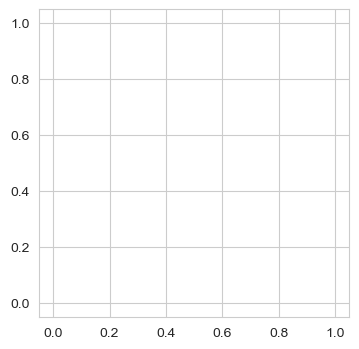


t = 0.1
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [1 1 1 1 1 1 0 1 1 1]
FP = 4  TN = 1
TP = 5  FN = 0
[1.0, 0.8]
[1.0, 1.0]


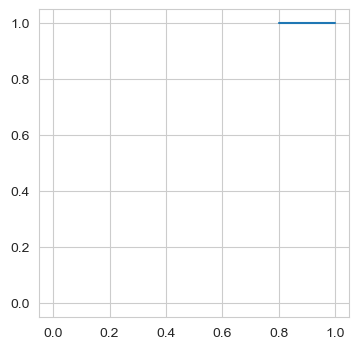


t = 0.2
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [1 1 1 1 1 1 0 0 1 0]
FP = 3  TN = 2
TP = 4  FN = 1
[1.0, 0.8, 0.6]
[1.0, 1.0, 0.8]


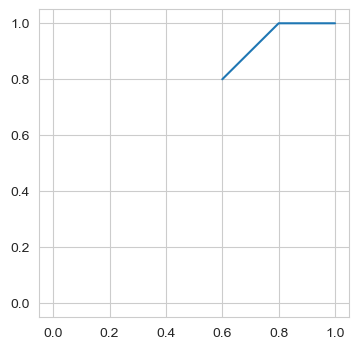


t = 0.3
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [1 1 1 1 1 1 0 0 0 0]
FP = 2  TN = 3
TP = 4  FN = 1
[1.0, 0.8, 0.6, 0.4]
[1.0, 1.0, 0.8, 0.8]


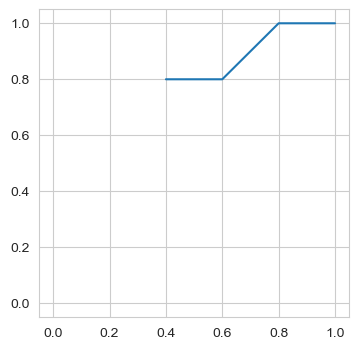


t = 0.4
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [1 1 1 1 1 0 0 0 0 0]
FP = 1  TN = 4
TP = 4  FN = 1
[1.0, 0.8, 0.6, 0.4, 0.2]
[1.0, 1.0, 0.8, 0.8, 0.8]


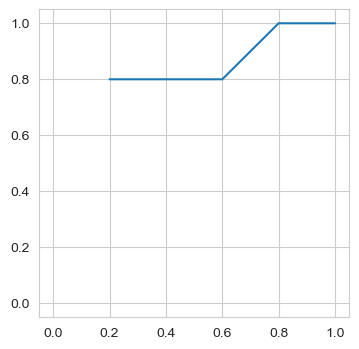


t = 0.5
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [1 1 0 1 1 0 0 0 0 0]
FP = 0  TN = 5
TP = 4  FN = 1
[1.0, 0.8, 0.6, 0.4, 0.2, 0.0]
[1.0, 1.0, 0.8, 0.8, 0.8, 0.8]


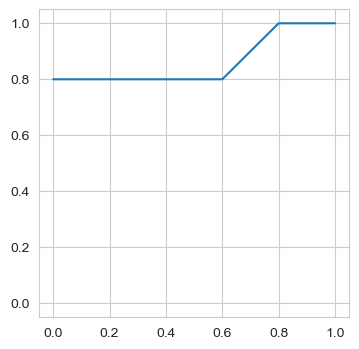


t = 0.6
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [1 0 0 1 1 0 0 0 0 0]
FP = 0  TN = 5
TP = 3  FN = 2
[1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.0]
[1.0, 1.0, 0.8, 0.8, 0.8, 0.8, 0.6]


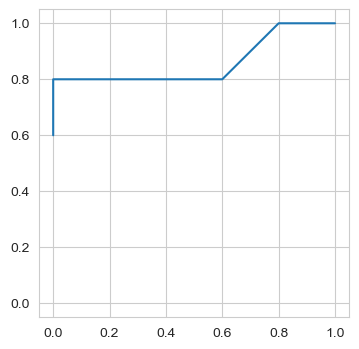


t = 0.7
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [0 0 0 1 1 0 0 0 0 0]
FP = 0  TN = 5
TP = 2  FN = 3
[1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.0, 0.0]
[1.0, 1.0, 0.8, 0.8, 0.8, 0.8, 0.6, 0.4]


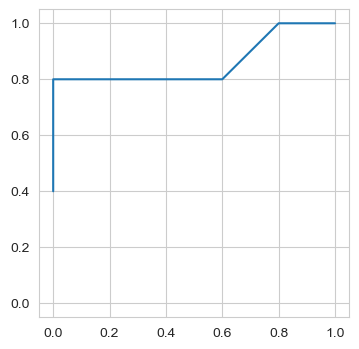


t = 0.8
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [0 0 0 0 0 0 0 0 0 0]
FP = 0  TN = 5
TP = 0  FN = 5
[1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.0, 0.0, 0.0]
[1.0, 1.0, 0.8, 0.8, 0.8, 0.8, 0.6, 0.4, 0.0]


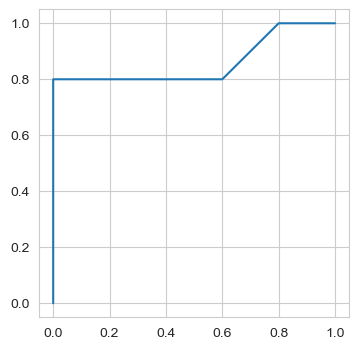


t = 1
y_true = [1 1 0 1 1 0 0 1 0 0]
y_pred = [0 0 0 0 0 0 0 0 0 0]
FP = 0  TN = 5
TP = 0  FN = 5
[1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 1.0, 0.8, 0.8, 0.8, 0.8, 0.6, 0.4, 0.0, 0.0]


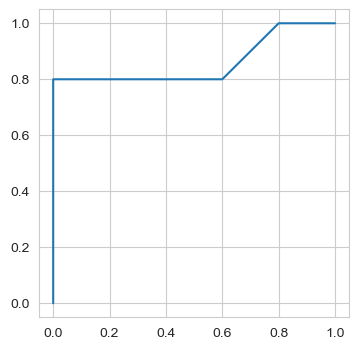

In [8]:
FPR = []
TPR = []

for t in threshold_list:
    
    print('')
    print('t =', t)
    y_pred = (y_pred_proba_B > t).astype(int)
    print('y_true =', y_true)
    print('y_pred =', y_pred)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    print('FP =', FP, ' TN =', TN)
    print('TP =', TP, ' FN =', FN)

    if (FP + TN != 0) and (FP + TN != 0):

        FPR.append(FP/(FP + TN))
        TPR.append(TP/(TP + FN))
    
    print(FPR)
    print(TPR)
    
    plt.figure(figsize = (4, 4))
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.plot(FPR, TPR)
    plt.show()

Вы заметили, как она себя ведёт? Кривая «растёт» из правого верхнего угла в левый нижний. Нет, это не ошибка — это логика процесса. При низком пороге мы хватаем вообще всех, и FPR, и TPR высоки. При высоком пороге — мы привередливы, никого не пускаем, и обе координаты падают. Кривая проживает целую драму — от безудержного оптимизма до сурового скептицизма.

А теперь — попробуйте сделать то же самое для модели A. Не ленитесь, коллеги. Наука — это не только вдохновение, но и рутинная работа с циклами.

>#### Задание 2.
Постройте ROC-кривую для модели A.

In [ ]:
# Код

### 2.3. Площадь под ROC-кривой

Итак, у нас есть две кривые. Мы их построили, мы на них посмотрели — и, признаюсь честно, даже немного загордились собой. Но теперь наступает момент истины. Потому что просто смотреть на кривые и говорить «ну, эта вроде покрасивее» — это, знаете ли, не метод. А мы с вами, коллеги, люди серьёзные. Нам нужны числа.

Давайте, просто исходя из наглядной геометрии, посчитаем площади под ними. Смотрим на кривые, разбиваем фигуры на прямоугольники и трапеции и считаем площади просто по формулам школьной математики. Никакой магии. Никакого машинного обучения. Четвёртый класс, раздел «Площади фигур», помните? Вот и славно.

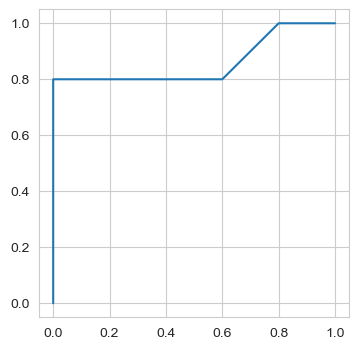

In [11]:
FPR = []
TPR = []

for t in threshold_list:
    
    y_pred = (y_pred_proba_B > t).astype(int)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    if (FP + TN != 0) and (FP + TN != 0):

        FPR.append(FP/(FP + TN))
        TPR.append(TP/(TP + FN))

plt.figure(figsize = (4, 4))
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.plot(FPR, TPR)
plt.show()

Что мы имеем для модели B. Всматриваемся в кривую. Первый отрезок по оси X — от 0 до 0.6. Какой высоты наш прямоугольник? Правильно, 0.8. Дальше — участок от 0.6 до 0.8. Это уже трапеция: высота 0.2, левое основание 0.8, правое — 1. И, наконец, последний кусочек от 0.8 до 1 — снова прямоугольник высотой 1. Подставляем, считаем... И что же нам выдаёт наш непосредственный и милый, но иногда слишком буквальный Python?

In [12]:
0.6*0.8 + 0.2*(0.8 + 1)/2 + 0.2*1

0.8600000000000001

(Пауза. Многозначительный взгляд в потолок.)

Каким-то загадочным образом Python после выполнения таких примитивных операций умудрился вернуть какую-то не вполне точную величину. Но это его проблемы. Мы-то с вами понимаем, что это буквально та же самая величина метрики модели B, которую мы вычислили при помощи попарных сравнений вероятностей в §1. Разница между числами — на четырнадцатом знаке после запятой, и если вас это волнует, то у вас слишком много свободного времени.

Точно так же поступим с моделью A. Разбиваем, считаем, не жульничаем:

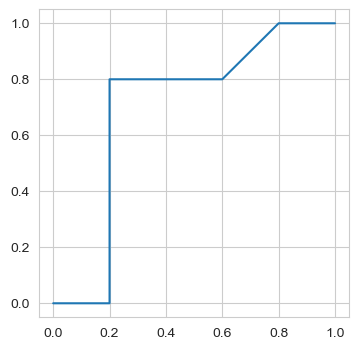

In [13]:
FPR = []
TPR = []

for t in threshold_list:
    
    y_pred = (np.array(y_pred_proba_A) > t).astype(int)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    if (FP + TN != 0) and (FP + TN != 0):

        FPR.append(FP/(FP + TN))
        TPR.append(TP/(TP + FN))
        
plt.figure(figsize = (4, 4))
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.plot(FPR, TPR)
plt.show()

И получаем:

In [14]:
0.4*0.8 + 0.2*(0.8 + 1)/2 + 0.2*1

0.7000000000000002

Это (если не считать какой-то ерунды, которую Python снова приписал в виде последнего символа после запятой) — та же самая величина метрики, которую мы посчитали в §1 для модели A.

Посмотрите на эти числа. 0.86 и 0.7. Модель B даёт площадь 0.86, модель A — 0.7. И это, заметьте, не какие-то абстрактные баллы. Это площади геометрических фигур. А площадь, как известно каждому, кто хоть раз клеил обои, — величина объективная.

Теперь у нас есть красивая геометрическая интерпретация: ROC-AUC — это просто площадь под ROC-кривой. Чем модель лучше упорядочивает объекты, тем ближе кривая к левому верхнему углу, тем больше площадь. Идеальный классификатор дал бы площадь 1. Монетка — площадь 0.5. А наши модели, как мы видим, монетками не являются — одна из них, правда, ближе к идеалу, чем другая.

### 2.4. Почему это одно и то же

А вот это — очень сложный вопрос. Я бы даже сказал — философский.

С одной стороны у нас — накопленный счётчик правильных, неправильных и неопределённых пар вероятностей, нормированный при помощи общего числа таких пар. Простая работа: перебрали пары, посчитали, поделили. С другой стороны — площадь геометрического объекта. Трапеции и прямоугольники, школьная геометрия.

Почему это одно и то же? 

Математическое доказательство точного равенства — возможно. Оно есть. Оно очень сложное, оно требует определённой смелости и, признаюсь, изрядной доли терпения. Когда-нибудь — когда я наконец преодолею свою врождённую лень — я буду показывать его студентам следующих поколений. Они будут сидеть, раскрыв рты, и думать: «Боже, какой же наш профессор умный, хотя и слегка невыносимый». А пока — прошу меня простить — примите на веру.

Но примите с уверенностью. Потому что это — правда. Метрики, посчитанные нами в §1 при помощи алгоритма перебора, и метрики, посчитанные нами в §2 при помощи наглядных геометрических соображений, — это одно и то же. Для любых моделей бинарной классификации. Если таковые, разумеется, умеют возвращать вероятность принадлежности к классу. Если ваша модель выдаёт только «да» или «нет» — извините, этот фокус не для вас.

И в этом, коллеги, заключается вся прелесть ROC-AUC как метрики. Она соединяет в себе две стихии: переборную — алгоритмическую, дискретную, почти ремесленную; и геометрическую — наглядную, непрерывную, красивую. Вы можете смотреть на неё как на вероятность того, что случайно выбранная единица окажется выше случайно выбранного нуля. А можете — как на площадь фигуры, которую вы нарисовали, соединив точки. И это — одно и то же.

Математика прекрасна именно этим: она позволяет нам смотреть на одну и ту же вещь с разных сторон и каждый раз узнавать её заново.

## § 3. Определения и предназначение метрики ROC-AUC

### 3.1. Общий алгоритм вычисления ROC-AUC вручную

>#### Задние 3.
Допустим, у нас есть некая модель бинарной классификации, которая вернула нам массив `y_test_proba` — вероятности принадлежности объектов к классу 1 на тестовой выборке. Пусть `y_test` — массив истинных значений. Напишите алгоритм, который принимает на вход массивы `y_test_proba` и `y_test` и вычисляет метрику ROC-AUC при помощи перебора правильных, неправильных и неопределенных пар вероятностей.

In [15]:
y_test       = [  1,   1,   0,   1,   1,   0,   0,   1,   0,   0]
y_test_proba = [0.7, 0.6, 0.9, 0.8, 0.8, 0.4, 0.1, 0.2, 0.3, 0.2]

# Формируем датафрейм из истинных меток на тесте и вероятностей их принадлежности классу 1, который вернула модель.
df_ra = pd.DataFrame()
df_ra['y_true'] = y_test
df_ra = df_ra.reset_index(drop=True)
df_ra['y_score'] = y_test_proba
display(df_ra)
# Берем локализацию для всех единичных меток
df_ra_1 = df_ra.loc[df_ra['y_true'] == 1]
df_ra_1 = df_ra_1.reset_index(drop=True)

# Берем локализацию для всех нулевых меток
df_ra_0 = df_ra.loc[df_ra['y_true'] == 0]
df_ra_0 = df_ra_0.reset_index(drop=True)

# Подсчитываем число ситуаций, когда вероятность единичной метки находится в "правильном" соотношении 
# с вероятностью нулевой метки (при этом учитываем возможность точного равенства).
count = 0
for a in df_ra_1['y_score']:
    for b in df_ra_0['y_score']:
        if a>b:
            count=count+1
        elif a==b:
            count=count+0.5
            
print('ROC-AUC_test_manual  =', round(count/(len(df_ra_1)*len(df_ra_0)), 4))
print('ROC-AUC_test_sklearn =', round(roc_auc_score(y_test, y_test_proba), 4))

# Берем отношение найденного числа к общему коничеству пар (единичная метка, нулевая метка)
# И проверяем равенство метрик. Да. Это действительно ROC-AUC, который посчитал sklearn.
round(count/(len(df_ra_1)*len(df_ra_0)), 4) == round(roc_auc_score(y_test, y_test_proba), 4)

,y_true,y_score
0,1,0.7
1,1,0.6
2,0,0.9
3,1,0.8
4,1,0.8
5,0,0.4
6,0,0.1
7,1,0.2
8,0,0.3
9,0,0.2


ROC-AUC_test_manual  = 0.7
ROC-AUC_test_sklearn = 0.7


True

Ну что? Написали? Симпатичный алгоритм, не правда ли? Не очень сложный — всего лишь вложенный цикл по двум локализациям, элегантный и прозрачный. Теперь, имея этот алгоритм, мы можем — легко и непринуждённо — вычислять метрику ROC-AUC любой модели бинарной классификации, которая умеет возвращать вероятности. И для этого нам даже не нужно рисовать никаких кривых. Никаких трапеций. Никаких площадей. Только перебор.


### 3.2. Эквивалентные определения

И вот тут начинается самое интересное. Причем заметьте:

1) Если у нас есть такой алгоритм, то мы можем вычислить площадь под ROC-кривой — не рисуя самой кривой, просто посчитав пары и получив число.  

2) И наоборот: если мы можем посчитать площадь под ROC-кривой, то мы можем получить результат работы такого алгоритма — не запуская его на исполнение.


На языке математики это называется — **эквивалентность**. Два разных взгляда на одну и ту же сущность, два разных описания одной и той же метрики. В учебниках пишут, что метрика ROC-AUC — это площадь под ROC-кривой. Собственно, даже сама аббревиатура об этом говорит: Receiver Operating Characteristic — Area Under Curve.

Но, извините меня, у нас есть альтернативное, эквивалентное определение. Почему бы не считать, что метрика ROC-AUC — это  результат перебора пар вероятностей?

Замечу, коллеги, что это отнюдь не исключительная ситуация. В математическом анализе, например, общепринятыми являются два эквивалентных определения предела функции в точке: определение Коши, основанное на бесконечно малых δ и ε, и определение Гейне, которое базируется на пределах последовательностей. И никого это не смущает. Математики просто используют то определение, которое лучше подходит для доказательства их теорем. Или для объяснения студентам.  

Возможно, определение ROC-AUC именно как площади под кривой когда-то имело смысл. Только это было очень давно — во время Второй мировой войны, когда эта метрика возникла в теории обнаружения сигналов. Когда она была инструментом проектирования средств ПВО, и площадь под кривой действительно говорила: «Насколько хорошо наш радар отличает бомбардировщик от стаи птиц?»  

Но я беру на себя смелость утверждать: в области машинного обучения такое определение не объясняет ровным счётом ничего. Оно только путает студентов. И само название путает. Гораздо правильнее было бы называть эту метрику не ROC-AUC, а, например, «метрикой попарных сравнений вероятностей» — Pairwise Probability Comparisons, PPC. Или как-нибудь ещё. По крайней мере, было бы сразу понятно, о чём речь.  

Но — увы. История сильнее нас, и мы продолжаем называть её ROC-AUC. 

### 3.3. Визуальная роль ROC-кривой

А зачем тогда нужна ROC-кривая?


Вопрос резонный. И ответ на него, если честно, слегка обескураживает: при желании на ROC-кривую можно вообще внимания не обращать. Она не является ни необходимым, ни достаточным условием для понимания метрики. Лично я воспринимаю ее как красивую безделушку — изящный график, который приятно рассматривать, но который не объясняет ровно ничего из того, что действительно важно. Если вы хотите понять, как работает ROC-AUC, забудьте про кривую и вспомните про пары вероятностей. Кривая — это просто картинка к опере.


Но если вам так хочется (а некоторым хочется, я знаю), то рассматривайте ROC-кривую как удобную — впрочем, не такую уж и удобную — визуализацию для сравнения двух метрик двух моделей. Да, она позволяет на одном графике увидеть, чья кривая выше и, следовательно, чья площадь под ней больше. Это может быть полезно в презентациях, в отчетах, в разговоре с заказчиком, который любит «красивые графики». Но для реальной диагностики модели она вряд ли является хорошим вариантом.


### 3.4. Предназначение метрики ROC-AUC

И опять о несовершенстве учебников по машинному обучению. Я не устаю поражаться этому, но почему-то их авторы с завидным упорством утверждают, что ROC-AUC — это метрика бинарной классификации. Это заблуждение настолько распространенное, что стало уже почти аксиомой. Позвольте мне с этой аксиомой не согласиться.

Применять ROC-AUC для оценки качества классификаторов — это примерно то же самое, что микроскопом гвозди забивать. Можно. Технически возможно. Но, во-первых, не очень удобно — молотком удобнее. А во-вторых, микроскоп, если вы вдруг забыли, вообще-то предназначен для других задач.


ROC-AUC — это **метрика для оценки качества ранжирования**. Когда для нас имеет значение не столько то, насколько точно модель отнесла объект к тому или иному классу, сколько то, в каком порядке следуют эти объекты в зависимости от их оценок. И в этом смысле контекст бизнес-задачи играет огромную роль. Именно контекст решает: использовать ROC-AUC или действительные метрики классификации — accuracy, precision, recall, F1. Это разные миры. Их нельзя путать.


Классический пример — задача банковского скоринга. Это когда банк решает, давать ли клиенту кредит. Если мы скажем: «Вероятность дефолта — 0.47», то это ни о чём не говорит. А вот если мы проранжируем всех клиентов по вероятности дефолта, скажем: «Вот эти 20% — самые рискованные, им отказываем, а остальных пускаем» — то это уже бизнес-решение. Нам важно не число, а порядок следования. Нам важно, чтобы первые 5% кредитного портфеля действительно оказались самыми надёжными, а последние 5% — самыми рисковыми. ROC-AUC проверяет именно это: насколько хорошо модель упорядочила объекты.

Но есть и другие задачи, где на первый план выходит ранжирование, а не классификация. Это поисковая выдача — где важно, чтобы первый результат был самым релевантным, а не просто чтобы он был «релевантным» или «нерелевантным». Это рекомендательные системы — где критично, чтобы пользователю первым показывался самый интересный фильм. И так далее. Везде — порядок следования, порядок следования и ещё раз порядок следования.


### 3.5. Другие метрики ранжирования

И, конечно, было бы наивно полагать, что ROC-AUC — единственная метрика ранжирования. Для оценки качества упорядочивания объектов применяются и другие, не менее уважаемые показатели. С умным видом перечислю самые популярные из них, чтобы вы поняли масштаб явления:

- **Gini** — тот же ROC-AUC, но домноженный на два и сдвинутый. Любимец банковских аналитиков, потому что они любят, чтобы всё было в процентах и называлось «коэффициентом».

- **MAP (Mean Average Precision)** — метрика, которая усредняет точность на разных уровнях полноты. Очень популярна в информационном поиске.

- **NDCG (Normalized Discounted Cumulative Gain)** — учитывает не только порядок, но и «вес» каждого объекта на своей позиции. Чем выше релевантный объект, тем лучше. Чем ниже — тем меньше штраф.

- **MRR (Mean Reciprocal Rank)** — смотрит только на позицию первого релевантного объекта. Идеально для вопросно-ответных систем.

Мы не будем на них подробно останавливаться — это тема для отдельной объемной лекции. Просто имейте в виду: они есть. У каждой своя область применения. Своя философия. Свои тонкости. Но в любом случае ROC-AUC остаётся наиболее популярной из них. Не самой лучшей. Не самой точной. Но точно — самой популярной.

## § 4. Менее игрушечный пример

>#### Задание 4
Прочитайте файл `blank_and_numbers.csv`.

In [ ]:
# Код

#### Контекст


Юридическая фирма «Квитанция & Циферки» специализируется на банкротстве юридических лиц. У компании есть сайт, на который заходят потенциальные клиенты, однако оформление заказа происходит только при личном визите в офис. Текущая стратегия — обзвон всех посетителей сайта — неэффективна и требует много ресурсов. Задача бизнеса — предсказывать, какие посетители сайта с наибольшей вероятностью в итоге заключат договор, чтобы сосредоточить усилия колл-центра на этих клиентах.

#### Датасет

- session_count — количество сессий на сайте (int),
- device_type — тип устройства (смартфон, планшет, ПК) (str),
- pages_viewed — количество просмотренных страниц (int),
- time_on_site — общее время на сайте в минутах (float),
- key_pages_viewed — количество просмотров ключевых страниц («Услуги», «О компании», «Контакты») (int),
- consultation_requested — запрашивал ли консультацию через форму обратной связи (0 — нет, 1 — да) (int),
- visit_time_of_day — время суток посещения сайта (утро, день, вечер, ночь) (str),
- weekend — посещение пришлось на выходной день (0 — будни, 1 — выходной) (int).


#### Таргет

- order_made — клиент заключил договор на банкротство (0 — нет, 1 — да) (int). Сильный дисбаланс: большинство посетителей не становится клиентами (ориентировочно 90–95% — 0, 5–10% — 1). Для бизнеса важно находить именно тех немногих, кто склонен к заказу, чтобы не тратить ресурсы на бесперспективные звонки.


#### Бизнес-задача


Предсказывать вероятность совершения заказа (order_made) по поведенческим признакам на сайте. Полученные вероятности позволяют ранжировать посетителей по степени готовности к сотрудничеству и передавать в колл-центр только тех, кто входит в топ-группу наиболее перспективных лидов. Это задача ранжирования, поэтому метрика ROC-AUC подходит для оценки качества модели.

#### Задание 5
При помощи метода `apply` замените строковые значения на числовые:

- в признаке `'device_type'`: смартфон на 1, планшет на 2, ПК на 3.
- в признаке `'visit_time_of_day'`: утро на 1, день на 2, вечер на 3, ночь на 4.

In [ ]:
# Код

>#### Задание 6
Обучите модель бинарной классификации.

In [ ]:
# Код

>#### Задание 7
Используя методы `roc_auc_score`, `roc_curve` из библиотеки sklearn вычислите метрику ROC-AUC и постройте ROC-кривую.

In [ ]:
# Код

## Домашее задание

#### Задание 1
Прочитайте файл `'paw_of_help.csv'`.

In [ ]:
# Код

#### Контекст

Страховая компания «Лапа Помощи» специализируется на страховании домашних животных. Компания предлагает клиентам оформить полис онлайн, но многие пользователи заполняют заявку и бросают её на полпути. Чтобы увеличить конверсию в оформление полиса, компания хочет предсказывать, какие посетители сайта с наибольшей вероятностью купят полис. Это позволит направить на них усилия отдела продаж (звонок или персональная скидка).

#### Датасет

- time_on_site — время на сайте (секунды) (int),
- pages_viewed — количество просмотренных страниц (int),
- breed_page_viewed — смотрел ли страницу с породами животных (0 — нет, 1 — да) (int),
- calculator_used — воспользовался ли калькулятором стоимости полиса (0 — нет, 1 — да) (int),
- device_type — тип устройства: 0 — смартфон, 1 — планшет, 2 — ПК (int),
- age_of_pet — возраст питомца (годы) (int, 0–15),
- previous_claims — было ли страховое возмещение ранее (0 — нет, 1 — да) (int),
- visit_month — месяц посещения (1–12) (int).

#### Таргет

- policy_purchased — клиент купил полис (0 — нет, 1 — да) (int). Сильный дисбаланс: примерно 90–93% посетителей не покупают полис, 7–10% покупают. Бизнесу важно искать тех немногих, кто готов к покупке, чтобы не тратить ресурсы на бесперспективные звонки.

#### Бизнес-задача

Предсказывать вероятность покупки полиса (policy_purchased) по поведенческим признакам на сайте. Полученные вероятности позволяют ранжировать посетителей по готовности к сотрудничеству и передавать в отдел продаж только тех, кто входит в топ наиболее перспективных лидов. Это задача ранжирования, поэтому метрика ROC-AUC подходит для оценки качества модели.

>#### Задание 2
Обучите модель бинарного классификатора, вычислите метрику ROC-AUC и постройте ROC-кривую.

In [ ]:
# Код